<h1 style="text-align: center;">Network Anomaly Detection System using Machine Learning</h1>

Train shape: (82332, 45)
Test shape: (175341, 45)


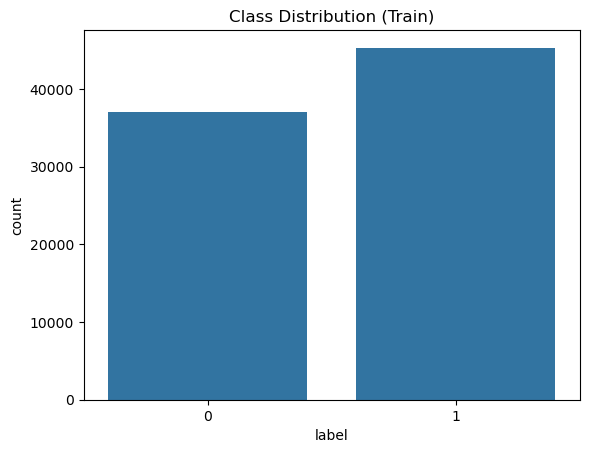

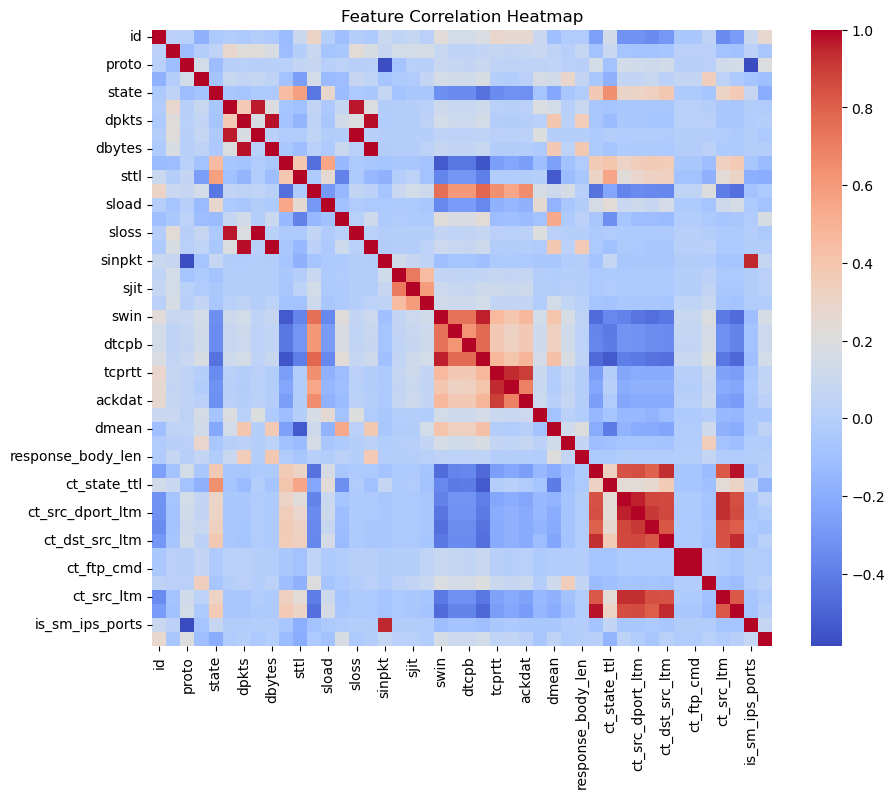


Accuracy: 0.9510439657581513

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93     56000
           1       1.00      0.93      0.96    119341

    accuracy                           0.95    175341
   macro avg       0.93      0.96      0.95    175341
weighted avg       0.96      0.95      0.95    175341



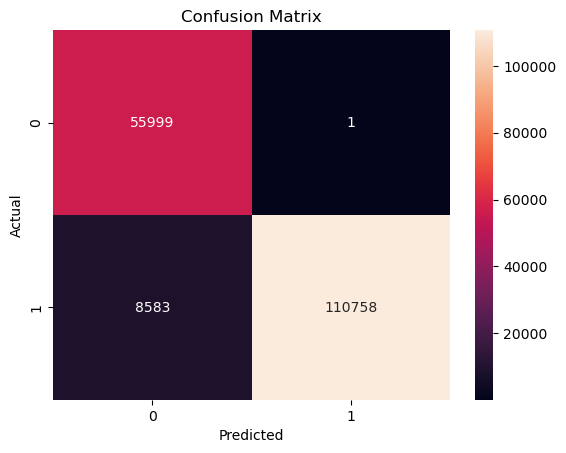

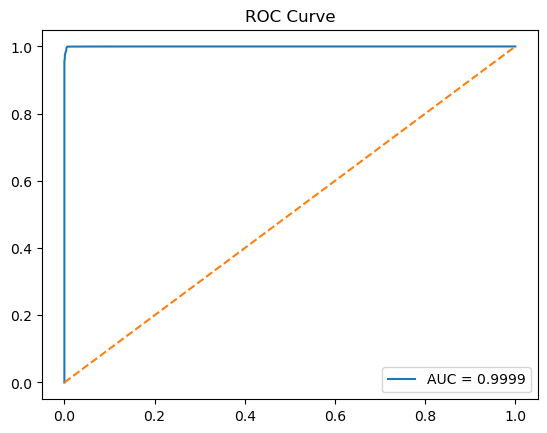

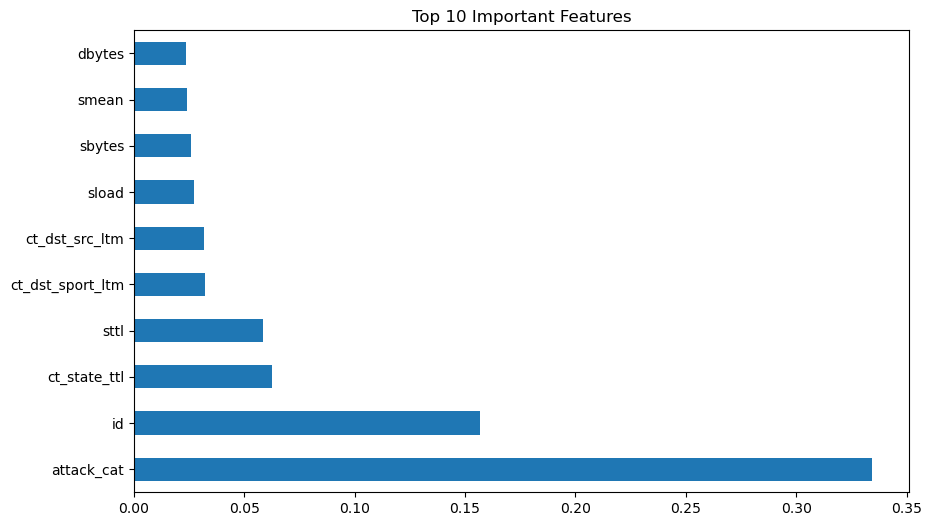

Cross-validation: [1.         1.         0.97953358 1.         0.978987  ]
Mean CV score: 0.9917041175756104
Model, scaler, and features saved!


In [6]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score

# =========================
# 2. LOAD DATA
# =========================
train_df = pd.read_csv("C:\\Users\\rohan\\OneDrive\\Document\\ML Project\\UNSW_NB15_training-set.csv")
test_df = pd.read_csv("C:\\Users\\rohan\\OneDrive\\Document\\ML Project\\UNSW_NB15_testing-set.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# =========================
# 3. DATA CLEANING
# =========================
for df in [train_df, test_df]:
    df.columns = df.columns.str.strip()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

# =========================
# 4. ENCODE CATEGORICAL DATA
# =========================
cat_cols = train_df.select_dtypes(include=['object']).columns

encoders = {}

for col in cat_cols:
    encoder = LabelEncoder()
    combined_values = pd.concat([train_df[col], test_df[col]], axis=0).astype(str)
    encoder.fit(combined_values)

    train_df[col] = encoder.transform(train_df[col].astype(str))
    test_df[col] = encoder.transform(test_df[col].astype(str))

    encoders[col] = encoder

# =========================
# 5. SPLIT FEATURES & TARGET
# =========================
X_train = train_df.drop(['label'], axis=1)
y_train = train_df['label']

X_test = test_df.drop(['label'], axis=1)
y_test = test_df['label']

# =========================
# 📊 6. VISUALIZATION - CLASS DISTRIBUTION
# =========================
plt.figure()
sns.countplot(x=y_train)
plt.title("Class Distribution (Train)")
plt.show()

# =========================
# 📊 7. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(10,8))
sns.heatmap(X_train.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# =========================
# 8. FEATURE SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 9. TRAIN MODEL
# =========================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# =========================
# 10. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 11. EVALUATION
# =========================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# =========================
# 📊 12. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================
# 📊 13. ROC CURVE
# =========================
y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.legend()
plt.show()

# =========================
# 📊 14. FEATURE IMPORTANCE
# =========================
importances = model.feature_importances_
feat_names = train_df.drop(['label'], axis=1).columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()

# =========================
# 15. CROSS VALIDATION
# =========================
scores = cross_val_score(model, X_train, y_train, cv=5)
print("Cross-validation:", scores)
print("Mean CV score:", scores.mean())

# =========================
# 16. SAVE MODEL
# =========================
joblib.dump(model, "unsw_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(feat_names.tolist(), "feature_names.pkl")

print("Model, scaler, and features saved!")